<a href="https://colab.research.google.com/github/Danielrlins/Workshop26.1/blob/main/dia_4/Desafio_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd

df = pd.read_csv('train.csv')

# Converter idade pra número
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Preencher valores nulos
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Remover colunas inúteis
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)


In [28]:
#Engenharia de recursos para melhorar a qualidade da variavel a ser passada no Ml
df['FamilySize'] = df['SibSp'] + df['Parch']


In [29]:
#Separar x e y
X = df.drop('Survived', axis=1)
y = df['Survived']


In [30]:
#Enconding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['Sex'] = le.fit_transform(X['Sex'])
X['Embarked'] = le.fit_transform(X['Embarked'])

#Treinar o modelo com a coluna sexo e com a origem territorial do passageiro

In [31]:
#Separa parte treino e parte teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
#Modelo
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, random_state=42)

In [33]:
#Avaliação
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Treino:", model.score(X_train, y_train))
print("Teste:", model.score(X_test, y_test))

print("Acurácia:", acc)
print(df['Survived'].value_counts())






Treino: 0.8609550561797753
Teste: 0.8044692737430168
Acurácia: 0.8044692737430168
Survived
0    549
1    342
Name: count, dtype: int64


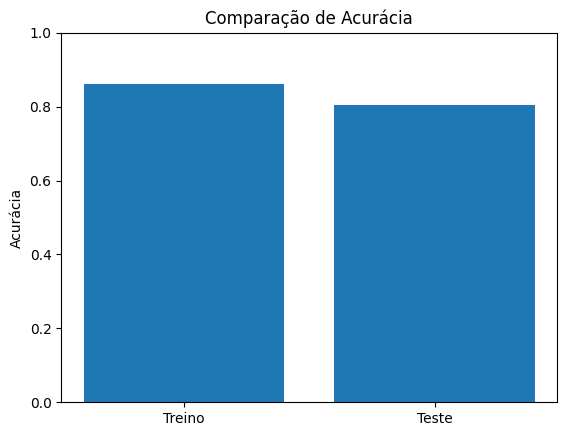

In [34]:
#Grafico de comparação(% de acuracia no treino + % de acuracia no teste)
import matplotlib.pyplot as plt

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

labels = ['Treino', 'Teste']
values = [train_acc, test_acc]

plt.figure()
plt.bar(labels, values)

plt.title('Comparação de Acurácia')
plt.ylabel('Acurácia')
plt.ylim(0, 1)

plt.show()


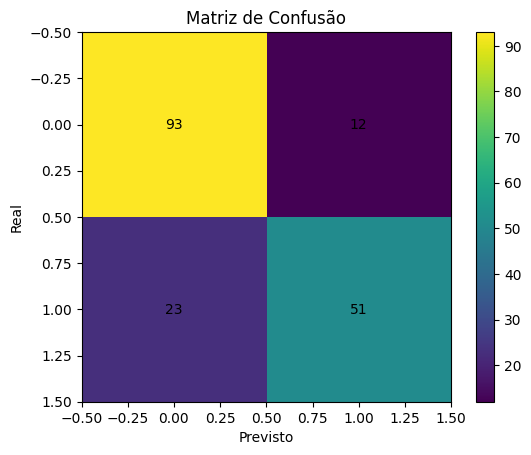

In [35]:
#Matriz de confusão- mostra onde o modelo erra e acerta
#Canto Superior direito = quem realmente morreu / Canto inferior direito = quem realmente sobreviveu
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure()
plt.imshow(cm)
plt.title('Matriz de Confusão')
plt.colorbar()

plt.xlabel('Previsto')
plt.ylabel('Real')

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()
